# ML Assignment 2 - Regression
## By Gladwin Thomas
## DS09

# Regression Assignment Objective:
### The objective of this assignment is to evaluate your understanding of regression techniques in supervised learning by applying them to a real-world dataset.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

## Dataset 

In [2]:
# Fetching dataset
data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [3]:
# Assigning X and y
X = pd.DataFrame(
    data = data['data'],
    columns = data['feature_names']
)
y = pd.DataFrame(
    data = data['target'],
    columns = data['target_names']
)

In [4]:
# Dataset X 
X 

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
# Target Dataset
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [6]:
# Checking for null values in X
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [7]:
# Checking for null values in y
y.isnull().sum()

MedHouseVal    0
dtype: int64

In [8]:
# Outliers
outliers = list()
for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    bound = IQR * 1.5
    outlier = X[(X[col] < (Q1 - bound)) | (X[col] > (Q3 + bound))]
    outliers.extend(outlier.index.tolist())
    
for col in y.columns:
    Q1 = y[col].quantile(0.25)
    Q3 = y[col].quantile(0.75)
    IQR = Q3 - Q1
    bound = IQR * 1.5
    outlier = y[(y[col] < (Q1 - bound)) | (y[col] > (Q3 + bound))]
    outliers.extend(outlier.index.tolist())

outlier_index = set(outliers)
print("Number of outliers: ", len(outlier_index))
X = X.drop(index=outlier_index)
y = y.drop(index=outlier_index)

Number of outliers:  4328


In [9]:
# Scaling 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.89914786, 1.        , 0.97433416, ..., 0.48271515, 0.5642933 ,
        0.21574642],
       [0.68319666, 1.        , 0.58948744, ..., 0.40790478, 0.5642933 ,
        0.21472393],
       [0.44281835, 1.        , 0.66183773, ..., 0.30009991, 0.5642933 ,
        0.21472393],
       ...,
       [0.15571281, 0.31372549, 0.49419273, ..., 0.34250901, 0.73219979,
        0.3200409 ],
       [0.17807981, 0.33333333, 0.51350219, ..., 0.28296247, 0.73219979,
        0.30981595],
       [0.24782952, 0.29411765, 0.50185206, ..., 0.4282127 , 0.72582359,
        0.31799591]], shape=(16312, 8))

In [10]:
# Splitting dataset to train and test dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Preprocessing steps performed are :
1. Handling missing values -> checked for existense of missing valeus, no missing values found
2. Perform scaling -> Scaling is performed so that each feature equal weightage and that no magnitude bias is formed.
3. Splitting data -> Split data to train and test data.

# Linear Regression
Linear Regression is an machine learning algorithm that helps to determine the relationship between the features and target using a linear equation. In this algorithm we try to fit a straight line to the data, such that error between the predicted and actual value is minimized.

The data has continuous values and have linear relationship with the target so linear regression is very suitable.

In [11]:
# Import libraries

from sklearn.linear_model import LinearRegression
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: [3.99660183]
Coefficient: [[ 3.37251384  0.54491661 -0.81748146  0.47457497  0.24795115 -1.25310315
  -3.69937128 -3.84368262]]


In [13]:
# Predictions
y_pred_lr = model.predict(X_test)

In [14]:
# Mean squared error of Linear Regression
mse = metrics.mean_squared_error(y_test, y_pred_lr)
print("MSE:", mse)

MSE: 0.3165222770544476


In [15]:
# Mean absolute error of Linear Regression
mae = metrics.mean_absolute_error(y_test, y_pred_lr)
print("MAE:", mae)

MAE: 0.42355274297359874


In [16]:
# R2 Score of Linear Regression
r2 = metrics.r2_score(y_test, y_pred_lr)
print("R2 Score:", r2)

R2 Score: 0.637896437482156


# Decision Tree Regeressor
Decision Tree Regressor is a tree based algorithm that helps us to split the data in such a way that we can obtain maximum information from the split. 

Decision Tree Regressor is good at capturing non-linear relationships.
No need of scaling data.

In [17]:
# Import Libraries
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [18]:
# Split the data without scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Initialize Decision Tree
dt = DecisionTreeRegressor(
    random_state=42, 
    max_depth = 5
)

# Train the model
dt.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [20]:
# Predict the values
y_pred_dt = dt.predict(X_test)


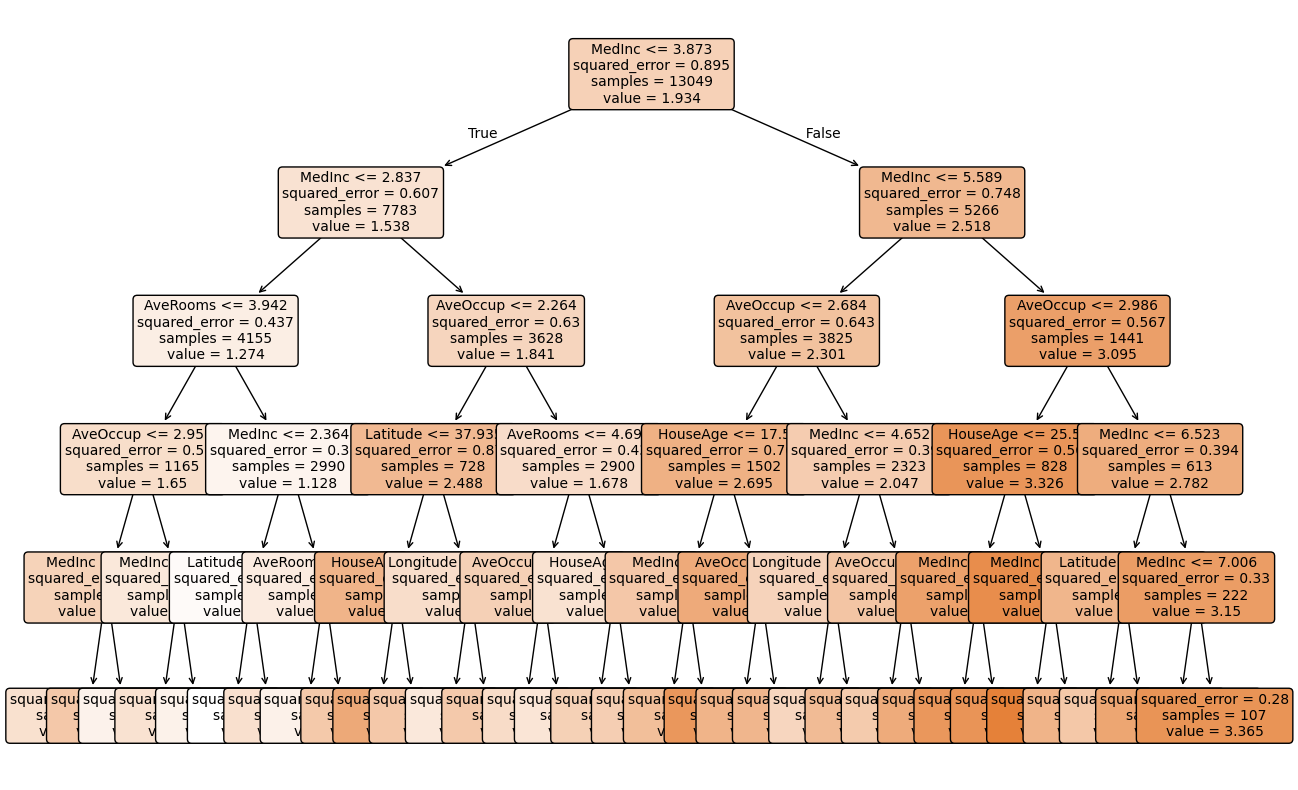

In [21]:
# To plot the decision tree
plt.figure(figsize=(15,10))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['Died','Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()


In [22]:
# Mean squared error of Decision Tree
mse = metrics.mean_squared_error(y_test, y_pred_dt)
print("MSE:", mse)

MSE: 0.39706186558946505


In [23]:
# Mean absolute error of Decision Tree
mae = metrics.mean_absolute_error(y_test, y_pred_dt)
print("MAE:", mae)

MAE: 0.47354624183070537


In [24]:
# R2 Score of Decision Tree
r2 = metrics.r2_score(y_test, y_pred_dt)
print("R2 Score:", r2)

R2 Score: 0.5457586195577813


# Model Evaluation and Comparison


## Best Performing Algorithm

The best performing algorithm is Linear Regression.
Compared to decision tree, it has lesser mean absolute error , lesser mean average error and better r2 score.
From this we can see that Linear Regression is able to better predict the median house values, compared to Decision Tree.

MAE tells us that the value predicted has an mean error of 420k usd. Which is a large error.

Linear Regression is able to better capture the linear relationships between features and unseen data. Though we are not able to get a viable model, with accuracy greater than 80%.

## Worst Performing Algorithm
Decision Tree is the worst performing algorithm for california housing. It is more sensitive to noise. It suffers from overfitting as it has high error when using test data.